# Kaggle - Brain Tumor MRI Dataset

You can find the dataset and some informations about on the [Kaggle page](https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset).

For details on steps below, please see documentation in the *docs* directory.

## Kaggle notebook setup
### Installations

In [1]:
!pip install mlflow --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 102.9 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 105.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 70.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.1/197.1 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 814.0/814.0 kB 49.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 18.5 MB/s eta 0:00:00


### Data location

In [2]:
import os
print(os.listdir('/kaggle/input/'))
print(os.listdir('/kaggle/input/radimagenet-densenet121-notop'))
print(os.listdir('/kaggle/input/brain-tumor-mri-preprocessed'))
print(os.listdir('/kaggle/input/brain-tumor-mri-preprocessed/processed'))
print(os.listdir('/kaggle/input/brain-tumor-heads-weights'))

['radimagenet-densenet121-notop', 'brain-tumor-heads-weights', 'brain-tumor-mri-preprocessed']
['RadImageNet-DenseNet121_notop.h5']
['processed']
['Validation', 'Training', 'Testing', '.gitkeep']
['brain_tumor_heads.weights.h5']


## General

In [3]:
import mlflow
import mlflow.tensorflow
from mlflow.tracking import MlflowClient
mlflow.set_tracking_uri("https://preachingly-nonabjuratory-marget.ngrok-free.dev")
mlflow.set_experiment("Brain_Tumor_Training")

2026-03-04 15:08:59.177545: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772636939.353470      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772636939.405181      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772636939.837640      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772636939.837682      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772636939.837685      55 computation_placer.cc:177] computation placer alr

<Experiment: artifact_location='mlflow-artifacts:/830660600119881173', creation_time=1769099937797, experiment_id='830660600119881173', last_update_time=1769099937797, lifecycle_stage='active', name='Brain_Tumor_Training', tags={'mlflow.experimentKind': 'custom_model_development'}, workspace='default'>

In [51]:
import numpy as np

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.models import Model

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score, accuracy_score, precision_score, recall_score
from sklearn.utils import resample

from scipy.stats import norm

import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from datetime import datetime
import math
import random

import cv2
from collections import defaultdict
from typing import Tuple, Optional, Union

In [5]:
tf.keras.mixed_precision.set_global_policy("mixed_float16")
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))
tf.config.list_physical_devices('GPU')

Num GPUs Available: 1


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [6]:
# path management
PROJECT_ROOT = '/kaggle/input'
PREP_DIR = PROJECT_ROOT + '/brain-tumor-mri-preprocessed/processed'
ARTEFACTS_DIR = PROJECT_ROOT + '/radimagenet-densenet121-notop'
BEST_HEAD_DIR = PROJECT_ROOT + '/brain-tumor-heads-weights'
OUTPUT_DIR = "kaggle/working/radcam_results"
os.makedirs(OUTPUT_DIR + "/correct", exist_ok=True)
os.makedirs(OUTPUT_DIR + "/errors", exist_ok=True)

CHECKPOINT_DIR = "/kaggle/working/checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
MODEL_DIR = "/kaggle/working/export_model"
os.makedirs(MODEL_DIR, exist_ok=True)

CLASSES = ["notumor", "glioma", "meningioma", "pituitary"]

# model parameters
IMG_SIZE = 260
SEED = 42

PROJECT_NAME = "BrainTumorMRI"
MODEL_TYPE = "DenseNet121"
TWO_HEAD = True
MODEL_NAME = f"{PROJECT_NAME}_{MODEL_TYPE}_{TWO_HEAD*"2Head"}"
FREEZE_BACKBONE = True
MASK_TUMOR_TYPE_LOSS = True
BATCH_SIZE = 32
DATA_AUGMENTATION = True

## Modeling

### Backbone

In [7]:
def get_backbone(IMG_SIZE, ARTEFACTS_DIR, FREEZE_BACKBONE):
    # 1. Create DenseNet121 WITHOUT weights
    backbone = DenseNet121(
        include_top=False,
        weights=None,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
    
    # 2. Load RadImageNet weights
    backbone.load_weights(ARTEFACTS_DIR + "/RadImageNet-DenseNet121_notop.h5")
    
    # 3. Freeze the backbone for firsts training
    backbone.trainable = not FREEZE_BACKBONE
    
    print("✅ RadImageNet DenseNet121 loaded successfully")
    
    return backbone

In [8]:
#backbone = get_backbone(IMG_SIZE, ARTEFACTS_DIR, FREEZE_BACKBONE)

In [9]:
#backbone.summary()

In [10]:
#w = backbone.weights[0].numpy()
#print("Mean:", np.mean(w), "Std:", np.std(w))

Model seems to be correctly loaded.

### Model definition

In [11]:
def get_model_data_augmentation(x):
    x = layers.RandomFlip("horizontal", seed=SEED)(x)
    x = layers.RandomZoom((-0.03,0.03),(-0.03,0.03), seed=SEED)(x)
    x = layers.RandomTranslation((-0.01,0.01),(-0.01,0.01), seed=SEED)(x)
    return x

In [12]:
def get_model_head_presence(x):
    x = layers.Dense(128, use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(1,activation='sigmoid',name="tumor_presence")(x)
    return x

In [13]:
def get_model_head_type(x):
    x = layers.Dense(128, use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(4,activation='softmax',name="tumor_type")(x)
    return x

In [14]:
def shared_head_part(inputs, backbone):
    # Data augmentation (training only)
    x = get_model_data_augmentation(inputs)
    # Backbone - force into inference
    x = backbone(x, training=False)

    # Copy backbone output exactly via Lambda (no trainable params)
    #x = layers.Lambda(lambda t: t, name='Top_Conv_Layer')(x)    
    x = layers.Conv2D(64, 3, strides=1, padding='same', activation='relu', name='Top_Conv_Layer', trainable=False)(x)
    
    # Shared head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.4)(x)

    return x

In [15]:
def assemble_heads(IMG_SIZE, backbone):
    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    
    x = shared_head_part(inputs, backbone)
    
    #Heads
    output_presence = get_model_head_presence(x)
    output_type = get_model_head_type(x)
    
    model = keras.Model(
        inputs=inputs,
        outputs={
            "tumor_presence": output_presence,
            "tumor_type": output_type
        },
        name='densenet_two_head'
    )

    return model

In [16]:
def get_loss_presence():
    return keras.losses.BinaryFocalCrossentropy(
        gamma=2.0,
        alpha=0.25 # to favorize tumor detection (penalize false negatives), but taking account that tumors are 75% of data
    )

In [17]:
#@keras.saving.register_keras_serializable()
@tf.keras.utils.register_keras_serializable()
def masked_sparse_cce(y_true, y_pred):
    tumor_present = tf.cast(y_true != 0, tf.float32)
    loss = tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred)
    loss = loss * tumor_present
    return tf.reduce_sum(loss) / (tf.reduce_sum(tumor_present) + 1e-6)

In [18]:
@tf.keras.utils.register_keras_serializable()
class MaskedSparseCategoricalAccuracy(tf.keras.metrics.Metric): # calculate accuracy, excluding "no_tumor" (because of mask)
    def __init__(self, name="masked_accuracy", **kwargs):
        super().__init__(name=name, **kwargs)
        self.total = self.add_weight(name="total", initializer="zeros")
        self.count = self.add_weight(name="count", initializer="zeros")

    def update_state(self, y_true, y_pred, sample_weight=None):
        # mask: only tumor
        mask = tf.cast(y_true != 0, tf.float32)

        y_pred_labels = tf.argmax(y_pred, axis=-1)
        matches = tf.cast(tf.equal(tf.cast(y_true, tf.int64), y_pred_labels), tf.float32)

        matches = matches * mask

        self.total.assign_add(tf.reduce_sum(matches))
        self.count.assign_add(tf.reduce_sum(mask))

    def result(self):
        return self.total / (self.count + 1e-6)

    def reset_states(self):
        self.total.assign(0.0)
        self.count.assign(0.0)


In [19]:
@tf.keras.utils.register_keras_serializable()
class MeningiomaRecall(tf.keras.metrics.Metric):
    def __init__(self, name="meningioma_recall", **kwargs):
        super().__init__(name=name, **kwargs)
        self.true_positives = self.add_weight(name="tp", initializer="zeros")
        self.false_negatives = self.add_weight(name="fn", initializer="zeros")

    def update_state(self, y_true, y_pred, sample_weight=None):
        # y_true = sparse labels (batch,)
        y_true = tf.cast(y_true, tf.int32)

        # y_pred = logits ou probabilités, shape (batch, num_classes)
        y_pred = tf.argmax(y_pred, axis=-1, output_type=tf.int32)

        # Meningioma class index = 2
        meningioma_mask = tf.equal(y_true, 2)

        tp = tf.reduce_sum(
            tf.cast(tf.logical_and(tf.equal(y_pred, 2), meningioma_mask), tf.float32)
        )
        fn = tf.reduce_sum(
            tf.cast(tf.logical_and(tf.not_equal(y_pred, 2), meningioma_mask), tf.float32)
        )

        self.true_positives.assign_add(tp)
        self.false_negatives.assign_add(fn)

    def result(self):
        return self.true_positives / (self.true_positives + self.false_negatives + 1e-8)

    def reset_state(self):
        self.true_positives.assign(0.0)
        self.false_negatives.assign(0.0)

In [20]:
@tf.keras.utils.register_keras_serializable()
class BinaryF1(tf.keras.metrics.Metric):
    def __init__(self, name="f1_score", threshold=0.5, **kwargs):
        super().__init__(name=name, **kwargs)
        self.threshold = threshold
        self.tp = self.add_weight(name="tp", initializer="zeros")
        self.fp = self.add_weight(name="fp", initializer="zeros")
        self.fn = self.add_weight(name="fn", initializer="zeros")

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_pred = tf.cast(y_pred > self.threshold, tf.float32)
        y_true = tf.cast(y_true, tf.float32)

        tp = tf.reduce_sum(y_true * y_pred)
        fp = tf.reduce_sum((1 - y_true) * y_pred)
        fn = tf.reduce_sum(y_true * (1 - y_pred))

        self.tp.assign_add(tp)
        self.fp.assign_add(fp)
        self.fn.assign_add(fn)

    def result(self):
        precision = self.tp / (self.tp + self.fp + 1e-7)
        recall = self.tp / (self.tp + self.fn + 1e-7)
        return 2 * precision * recall / (precision + recall + 1e-7)

    def reset_states(self):
        self.tp.assign(0)
        self.fp.assign(0)
        self.fn.assign(0)

In [21]:
def compile_model(model, masked_sparse_cce):
    loss_presence = get_loss_presence()
    
    loss_weight_presence = 1.0
    loss_weight_type = 1.3 # we give a little more weight to the classification of the type
    
    model.compile(
        optimizer=keras.optimizers.Adam(), # change learning_rate for 1e-4 in fine-tuning steps
        loss={
            "tumor_presence": loss_presence,
            "tumor_type": masked_sparse_cce,
        },
        
        loss_weights={
            "tumor_presence": loss_weight_presence,
            "tumor_type": loss_weight_type, 
        },
        
        metrics={
            "tumor_presence": [
                keras.metrics.BinaryAccuracy(name="accuracy"),
                keras.metrics.Recall(name="recall"),
                keras.metrics.Precision(name="precision"),
                BinaryF1(name="f1_score"),
                keras.metrics.AUC(name="auc")
            ],
            "tumor_type": [
                #"accuracy", 
                MaskedSparseCategoricalAccuracy(name="masked_accuracy"),
                MeningiomaRecall(),
            ],
        }
    )

    return model, loss_weight_presence, loss_weight_type

In [22]:
def get_model_built(IMG_SIZE, ARTEFACTS_DIR, FREEZE_BACKBONE):
    
    backbone = get_backbone(IMG_SIZE, ARTEFACTS_DIR, FREEZE_BACKBONE)
    model = assemble_heads(IMG_SIZE, backbone)

    return model

In [23]:
model = get_model_built(IMG_SIZE, ARTEFACTS_DIR, FREEZE_BACKBONE)
model, loss_weight_presence, loss_weight_type = compile_model(model, masked_sparse_cce)

I0000 00:00:1772636953.240059      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


✅ RadImageNet DenseNet121 loaded successfully


In [24]:
#model.summary()

## Streaming Training

In [25]:
def parse_tfrecord(example_proto):
    """
    Parse a single TFRecord example and convert grayscale → RGB.
    """
    feature_description = {
        "image": tf.io.FixedLenFeature([], tf.string),
        "label": tf.io.FixedLenFeature([], tf.int64),
    }

    example = tf.io.parse_single_example(example_proto, feature_description)

    # Deserialize image
    image = tf.io.parse_tensor(example["image"], out_type=tf.float32)

    # Shape after loading: (260, 260, 3)
    image.set_shape((260, 260, 3))

    label = tf.cast(example["label"], tf.int32)

    return image, label



def load_tfrecord_dataset(tfrecord_dir, shuffle=False, batch_size=1, repeat=False):
    """
    Load a TFRecord dataset from a directory.

    Args:
        tfrecord_dir (str or Path): Folder containing .tfrecord files
        shuffle (bool): Whether to shuffle files and samples
        batch_size (int): Batch size (can stay 1)
        repeat (bool): Repeat dataset indefinitely (for training)

    Returns:
        tf.data.Dataset
    """
    tfrecord_files = tf.io.gfile.glob(
        str(tfrecord_dir) + "/*.tfrecord"
    )

    ds = tf.data.TFRecordDataset(
        tfrecord_files,
        num_parallel_reads=tf.data.AUTOTUNE
    )

    ds = ds.map(
        parse_tfrecord,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    if shuffle:
        ds = ds.shuffle(buffer_size=512)

    if repeat:
        ds = ds.repeat()

    ds = ds.batch(batch_size)
    ds = ds.prefetch(tf.data.AUTOTUNE)

    return ds


In [26]:
TRAIN_DIR = PREP_DIR + "/Training"
VAL_DIR   = PREP_DIR + "/Validation"
TEST_DIR  = PREP_DIR + "/Testing"

train_ds = load_tfrecord_dataset(
    TRAIN_DIR,
    shuffle=True,
    batch_size=BATCH_SIZE,
    repeat=False
).prefetch(tf.data.AUTOTUNE)

val_ds = load_tfrecord_dataset(
    VAL_DIR,
    shuffle=False,
    batch_size=BATCH_SIZE,
    repeat=False
).prefetch(tf.data.AUTOTUNE)

"""
test_ds = load_tfrecord_dataset(
    TEST_DIR,
    shuffle=False,
    batch_size=BATCH_SIZE,
    repeat=False
).prefetch(tf.data.AUTOTUNE)
"""

'\ntest_ds = load_tfrecord_dataset(\n    TEST_DIR,\n    shuffle=False,\n    batch_size=BATCH_SIZE,\n    repeat=False\n).prefetch(tf.data.AUTOTUNE)\n'

In [27]:
def split_labels(image, label):
    """
    Create labels for a 2-head model.
    """
    tumor_present = tf.cast(label != 0, tf.float32)
    tumor_type = tf.cast(label, tf.int32)

    return image, {
        "tumor_presence": tumor_present,
        "tumor_type": tumor_type
    }


In [28]:
train_ds = train_ds.map(split_labels, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.map(split_labels, num_parallel_calls=tf.data.AUTOTUNE)

In [29]:
#for x, y in train_ds.take(1):
#    print("Image:")
#    print(x.dtype, x.shape)
#    print("\nLabels:")
#    for k, v in y.items():
#        print(k, v.dtype, v.shape)

In [30]:
def count_tfrecord_batches(directory_path, batch_size):
    """
    Count number of batches for a TFRecord dataset.

    Assumes:
    - 1 sample per TFRecord
    - batch_size is variable

    Returns:
    - number of batches = ceil(num_samples / batch_size)
    """
    directory_path = Path(directory_path)
    n_samples = len(list(directory_path.glob("*.tfrecord")))
    return math.ceil(n_samples / batch_size)


In [31]:
print(train_ds.element_spec)

(TensorSpec(shape=(None, 260, 260, 3), dtype=tf.float32, name=None), {'tumor_presence': TensorSpec(shape=(None,), dtype=tf.float32, name=None), 'tumor_type': TensorSpec(shape=(None,), dtype=tf.int32, name=None)})


In [32]:
#to_monitor = "val_tumor_presence_recall"
#mode = "max"
to_monitor = "val_tumor_type_loss"
mode = "min"

reduce_lr = ReduceLROnPlateau(
    monitor=to_monitor,
    mode=mode,
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

early_stopping = EarlyStopping(
    monitor=to_monitor,
    mode=mode,
    min_delta=0.00001,
    patience=10,
    restore_best_weights=False,
    verbose=1,
)

checkpoint_cb = keras.callbacks.ModelCheckpoint(
    filepath=CHECKPOINT_DIR + "/epoch_{epoch:02d}.weights.h5",
    monitor=to_monitor,
    mode=mode,
    save_best_only=False,
    save_weights_only=True,
    verbose=1,
)

terminate_nan = keras.callbacks.TerminateOnNaN()

In [33]:
#print("RUN_NAME:", RUN_NAME)
#print("TRAIN steps:", count_tfrecord_batches(TRAIN_DIR, BATCH_SIZE))
#print("VAL steps:", count_tfrecord_batches(VAL_DIR, BATCH_SIZE))
#print("train_ds element_spec:", train_ds.element_spec)

In [34]:
raise Exception("Do not fit from scratch again. Use the best head model !")

RUN_NAME = (
    f"{MODEL_TYPE}"
    f"freeze={FREEZE_BACKBONE}_"
    f"mask={MASK_TUMOR_TYPE_LOSS}_"
    f"{datetime.now().strftime('%Y%m%d-%H%M')}"
)

print(f"Run name: {RUN_NAME}\n")

with mlflow.start_run(run_name=RUN_NAME):

    mlflow.tensorflow.autolog(registered_model_name=MODEL_NAME)

    mlflow.log_params({
        "project": PROJECT_NAME,
        "model_type": MODEL_TYPE,
        "pretrained_weights": "RadImageNet",
        "backbone_frozen": FREEZE_BACKBONE,
        "head_1": "tumor_presence_binary",
        "head_2": "tumor_type_softmax",
        "loss_weight_presence": loss_weight_presence,
        "loss_weight_type": loss_weight_type,
        "mask_tumor_type_loss": MASK_TUMOR_TYPE_LOSS,
        "label_0_means": "no_tumor",
        "data_augmentation": DATA_AUGMENTATION,
    })

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=80,
        #steps_per_epoch=count_tfrecord_batches(TRAIN_DIR, BATCH_SIZE),
        #validation_steps=count_tfrecord_batches(VAL_DIR, BATCH_SIZE),
        callbacks=[reduce_lr, early_stopping, checkpoint_cb, terminate_nan],
        verbose=1,
    )

    client = MlflowClient()
    latest_version = client.get_latest_versions(MODEL_NAME)[-1].version

    client.transition_model_version_stage(
        name=MODEL_NAME,
        version=latest_version,
        stage="Staging"
    )


Exception: Do not fit from scratch again. Use the best head model !

## Epoch filter

In [ ]:
history_df = pd.DataFrame(history.history)
history_df["epoch"] = history_df.index
#history_df.head(5)

In [ ]:
metrics_cols = [
    "epoch",
    "val_tumor_presence_recall",
    "val_tumor_type_accuracy",
    "val_tumor_presence_loss",
    "val_tumor_type_loss"
]

df = history_df[metrics_cols].copy()

In [ ]:
df = df[
    (df["val_tumor_presence_recall"] >= 0.94) &
    (df["val_tumor_type_accuracy"] >= 0.55)
]
#df

In [ ]:
def normalize(col):
    return (col - col.min()) / (col.max() - col.min() + 1e-8)

df["pres_rec_norm"] = normalize(df["val_tumor_presence_recall"])
df["type_accu_norm"] = normalize(df["val_tumor_type_accuracy"])
df["pres_loss_norm"] = 1 - normalize(df["val_tumor_presence_loss"])
df["type_loss_norm"] = 1 - normalize(df["val_tumor_type_loss"])

In [ ]:
df["S"] = (
    0.40 * df["pres_rec_norm"]
  + 0.35 * df["type_accu_norm"]
  + 0.15 * df["pres_loss_norm"]
  + 0.10 * df["type_loss_norm"]
)
#df

In [ ]:
best_row = df.sort_values("S", ascending=False).iloc[0]
best_epoch = int(best_row["epoch"])

print(f"✅ Best epoch selected from S: {best_epoch}")
print(best_row)

In [ ]:
mlflow.set_tags({
    "model_stage": "best_manual_epoch",
    "best_epoch": best_epoch,
    "selection_method": "composite_score_S",
})

mlflow.log_metric("S", best_row.iloc[-1])
mlflow.log_metric("Best epoch", best_row.iloc[0])

In [ ]:
raise Exception("Do not fit from scratch again. Use the best head model !")
model.load_weights(f"{CHECKPOINT_DIR}/epoch_{best_epoch:02d}.weights.h5")
print(f"✅ Loaded best epoch: {best_epoch}")

In [ ]:
raise Exception("Do not fit from scratch again. Use the best head model !")
mlflow.tensorflow.log_model(
    model,
    name=f"best_epoch_{best_epoch}_manual",
    registered_model_name=MODEL_NAME
)
print(f"✅ Registered best model: {MODEL_NAME}")

In [ ]:
raise Exception("Do not fit from scratch again. Use the best head model !")
model.save(f"{MODEL_DIR}/brain_tumor_model_best_epoch_{best_epoch}.keras")
model.save_weights(
    f"{MODEL_DIR}/brain_tumor_weights_epoch_{best_epoch}.weights.h5"
)
mlflow.log_artifacts(MODEL_DIR, artifact_path="exported_model_files")

### Loading final model from MLFlow

In [ ]:
#model = mlflow.tensorflow.load_model(
#    "models:/BrainTumorMRI_DenseNet121_2Head/latest"
#)
#print("✅ Model loaded successfully with custom loss")

In [ ]:
model = get_model_built(
    IMG_SIZE,
    ARTEFACTS_DIR,
    FREEZE_BACKBONE=False
)

model.load_weights(BEST_HEAD_DIR + "/brain_tumor_heads.weights.h5")

print("✅ Model reconstructed + weights loaded")
model, _, _ = compile_model(model, masked_sparse_cce)

In [ ]:
model, _, _ = compile_model(model, masked_sparse_cce)
model.evaluate(val_ds)

## Head control and explicability

### Confusion Matrix

In [ ]:
# Predictions on val_ds
y_true_type = []
y_pred_type = []

for x_batch, y_batch in val_ds:
    preds = model.predict(x_batch)
    y_true_type.extend(y_batch["tumor_presence"].numpy().astype(int).flatten())
    y_pred_type.extend((preds['tumor_presence'] > 0.5).astype(int).flatten())

cm = confusion_matrix(y_true_type, y_pred_type)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["no tumor", "tumor"])
disp.plot(cmap='Blues')

In [ ]:
# Predictions on val_ds
y_true_type = []
y_pred_type = []

for x_batch, y_batch in val_ds:
    preds = model.predict(x_batch)
    y_true_type.extend(y_batch['tumor_type'].numpy())
    y_pred_type.extend(preds['tumor_type'].argmax(axis=-1))

cm = confusion_matrix(y_true_type, y_pred_type)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES)
disp.plot(cmap='Blues')

### Grad-CAM

In [ ]:
# grad-cam parameters
LAST_CONV_LAYER = "conv5_block16_2_conv"
BACKBONE_NAME = "densenet121"

In [ ]:
model = get_model_built(
    IMG_SIZE,
    ARTEFACTS_DIR,
    FREEZE_BACKBONE=False
)

model.load_weights(
    BEST_HEAD_DIR + "/brain_tumor_heads.weights.h5"
)

print("✅ Model reconstructed + weights loaded")

In [ ]:
def build_gradcam_model(model, head_name='tumor_presence'):
    """
    Build a Grad-CAM model directly connected to the backbone + frozen Conv2D layer.
    
    Args:
        model: Original multi-head model
        head_name: 'tumor_presence' or 'tumor_type'
    
    Returns:
        gradcam_model: tf.keras.Model with outputs [Top_Conv_Layer, selected head]
    """
    # Output of frozen Conv2D
    conv_layer = model.get_layer('Top_Conv_Layer').output

    # Output of the selected head
    if head_name == 'tumor_presence':
        head_output = model.get_layer('tumor_presence').output
    elif head_name == 'tumor_type':
        head_output = model.get_layer('tumor_type').output
    else:
        raise ValueError(f"Unknown head_name {head_name}")
    
    gradcam_model = Model(inputs=model.inputs, outputs=[conv_layer, head_output])
    return gradcam_model

In [ ]:
def compute_gradcam(gradcam_model, img, target_head_name):
    """
    Compute standard Grad-CAM heatmap.
    """

    if len(img.shape) == 3:
        img = tf.expand_dims(img, axis=0)

    with tf.GradientTape() as tape:
        conv_outputs, preds = gradcam_model(img, training=False)

        if target_head_name == 'tumor_presence':
            loss = preds[:, 0]
        else:
            loss = tf.reduce_max(preds, axis=-1)

    # Gradient w.r.t. conv layer
    grads = tape.gradient(loss, conv_outputs)

    # 1️⃣ Global Average Pooling of gradients
    weights = tf.reduce_mean(grads, axis=(1, 2))

    # 2️⃣ Weighted sum of feature maps
    cam = tf.reduce_sum(
        weights[:, tf.newaxis, tf.newaxis, :] * conv_outputs,
        axis=-1
    )

    # 3️⃣ ReLU
    cam = tf.nn.relu(cam)

    # 4️⃣ Normalize
    cam = cam[0].numpy()
    p_low, p_high = np.percentile(cam, (5, 95))
    cam = np.clip((cam - p_low) / (p_high - p_low + 1e-8), 0, 1)

    return cam


In [ ]:
def compute_gradcam_pp(gradcam_model, img, target_head_name):
    """
    Compute Grad-CAM++ heatmap for a single image.
    
    Args:
        gradcam_model: model with outputs [Top_Conv_Layer, target_head_output]
        img: tf.Tensor, shape (H,W,3) or (1,H,W,3)
    
    Returns:
        cam: numpy array, normalized heatmap
    """
    # Add batch dimension if necessary
    if len(img.shape) == 3:
        img = tf.expand_dims(img, axis=0)
    
    with tf.GradientTape() as tape:
        tape.watch(img)
        # Compute forward pass
        conv_outputs, preds = gradcam_model(img, training=False)
        
        # Select target for gradient
        if target_head_name == 'tumor_presence':
            loss = preds[:, 0]
        else:
            # For multi-class, pick max logit
            loss = tf.reduce_max(preds, axis=-1)
    
    # Gradients w.r.t. conv layer
    grads = tape.gradient(loss, conv_outputs)
    
    # Grad-CAM++ alpha weights
    alpha_num = grads ** 2
    alpha_denom = 2 * grads ** 2 + tf.reduce_sum(conv_outputs * grads ** 3, axis=(1,2), keepdims=True)
    alpha_denom = tf.where(alpha_denom != 0.0, alpha_denom, tf.ones_like(alpha_denom))
    alpha = alpha_num / alpha_denom
    weights = tf.reduce_sum(alpha * tf.nn.relu(grads), axis=(1,2))
    cam = tf.reduce_sum(weights[:, tf.newaxis, tf.newaxis, :] * conv_outputs, axis=-1)
    
    # Normalize
    cam = tf.nn.relu(cam)
    cam = cam - tf.reduce_min(cam)
    cam = cam / (tf.reduce_max(cam) + 1e-8)
    cam = cam[0].numpy()  # remove batch dimension
    
    return cam

In [ ]:
def overlay_gradcam(original_image, heatmap, alpha=0.4):
    """
    Overlay Grad-CAM heatmap on original image, supports single or batched images.

    Args:
        original_image: numpy array or tf.Tensor, shape (H, W, 3) or (1, H, W, 3), values in [0,1]
        heatmap: numpy array or tf.Tensor, shape (h, w), values in [0,1]
        alpha: blending factor for overlay

    Returns:
        overlayed image, uint8, shape (H, W, 3)
    """
    # Convert TensorFlow tensors to numpy
    if isinstance(original_image, tf.Tensor):
        original_image = original_image.numpy()
    if isinstance(heatmap, tf.Tensor):
        heatmap = heatmap.numpy()

    # Remove batch dimension if present
    if original_image.ndim == 4:
        original_image = original_image[0]

    # Ensure float32 and clip values
    original_image = np.clip(original_image.astype(np.float32), 0, 1)
    heatmap = np.clip(heatmap.astype(np.float32), 0, 1)

    # Resize heatmap to match original image
    heatmap_resized = cv2.resize(heatmap, (original_image.shape[1], original_image.shape[0]))
    heatmap_resized = np.uint8(255 * heatmap_resized)

    # Apply color map
    heatmap_colored = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)
    
    #original_image -= original_image.min()
    #original_image /= (original_image.max() + 1e-8)
    # Overlay
    overlay = cv2.addWeighted(
        np.uint8(255 * original_image),
        1 - alpha,
        heatmap_colored,
        alpha,
        0
    )

    return overlay

In [ ]:
def get_grad_cam_overlay_img(model, tensor_img, head_name='tumor_presence', grad_cam_function=compute_gradcam_pp):
    model.training = False
    gradcam_model = build_gradcam_model(model, head_name)
    
    # Ensure batch dimension
    if len(tensor_img.shape) == 3:
        tensor_img = tf.expand_dims(tensor_img, 0)
    
    image_tensor = tf.cast(tensor_img, tf.float32)
    image_tensor = tf.Variable(image_tensor)  # watch for gradients
    
    heatmap = grad_cam_function(
        gradcam_model,
        image_tensor,
        target_head_name=head_name
    )

    orig_img = image_tensor[0].numpy()
    overlay = overlay_gradcam(orig_img, heatmap)

    plt.imshow(orig_img)
    plt.title("Original")
    plt.axis("off")
    plt.show()
    
    plt.imshow(overlay)
    plt.title("Grad-CAM")
    plt.axis("off")
    plt.show()


In [ ]:
val_ds = load_tfrecord_dataset(
    VAL_DIR,
    shuffle=False,
    batch_size=BATCH_SIZE,
    repeat=False
).prefetch(tf.data.AUTOTUNE)

In [ ]:
def get_image_by_index(dataset, idx):
    flat_ds = dataset.unbatch()
    img = flat_ds.skip(idx).take(1)
    img = next(iter(img))[0]
    return tf.expand_dims(img, axis=0)

In [ ]:
total_images = 0
for _ in val_ds.unbatch():
    total_images += 1

print("Total images:", total_images)


In [ ]:
idx = 1121
test_img = get_image_by_index(val_ds, idx)
print(test_img.shape)

In [ ]:
get_grad_cam_overlay_img(model, test_img, head_name='tumor_presence', grad_cam_function=compute_gradcam)
#get_grad_cam_overlay_img(model, test_img, head_name='tumor_presence', grad_cam_function=compute_gradcam_pp)

In [ ]:
get_grad_cam_overlay_img(model, test_img, head_name='tumor_type', grad_cam_function=compute_gradcam)
#get_grad_cam_overlay_img(model, test_img, head_name='tumor_type', grad_cam_function=compute_gradcam_pp)

___

In [ ]:
def get_diagnosis(model):
    print("="*70)
    print("DIAGNOSTIC DU MODÈLE")
    print("="*70)
    
    # Afficher la structure
    print("\n1. STRUCTURE DES COUCHES:")
    for i, layer in enumerate(model.layers):
        print(f"  {i:2d}. {layer.name:35s} - {type(layer).__name__}")
    
    # Tester l'accès aux têtes
    print("\n2. TEST ACCÈS AUX TÊTES:")
    for head_name in ["tumor_presence", "tumor_type"]:
        try:
            head = model.get_layer(head_name)
            print(f"  ✅ {head_name}: trouvée, type={type(head).__name__}")
            
            # Si c'est un Sequential, afficher ses couches
            if hasattr(head, 'layers'):
                print(f"     Contient {len(head.layers)} sous-couches")
                for j, sublayer in enumerate(head.layers):
                    print(f"       {j}. {sublayer.name}")
        except Exception as e:
            print(f"  ❌ {head_name}: ERREUR - {e}")
    
    # Tester l'accès au backbone
    print("\n3. TEST ACCÈS AU BACKBONE:")
    try:
        backbone = model.get_layer("densenet121")
        print(f"  ✅ Backbone trouvé")
        
        # Trouver les dernières conv
        conv_layers = [l for l in backbone.layers if 'conv' in l.name]
        print(f"  Dernières couches conv:")
        for layer in conv_layers[-5:]:
            print(f"    - {layer.name}")
    except Exception as e:
        print(f"  ❌ ERREUR: {e}")
    
    # Tester un forward pass
    print("\n4. TEST FORWARD PASS:")
    test_input = tf.random.normal((1, 260, 260, 3))
    try:
        output = model(test_input, training=False)
        print(f"  ✅ Forward pass réussi")
        print(f"  Type output: {type(output)}")
        if isinstance(output, dict):
            for key, val in output.items():
                print(f"    '{key}': {val.shape}")
    except Exception as e:
        print(f"  ❌ ERREUR: {e}")
    
    print("\n" + "="*70)

### Grad-CAM for confusion matrix categories

In [ ]:
model = get_model_built(
    IMG_SIZE,
    ARTEFACTS_DIR,
    FREEZE_BACKBONE=False
)

model.load_weights(BEST_HEAD_DIR + "/brain_tumor_heads.weights.h5")

print("✅ Model reconstructed + weights loaded")
model, _, _ = compile_model(model, masked_sparse_cce)

In [ ]:
def get_grad_cam_for_confusion_mtrx_presence(val_ds, grad_cam_function=compute_gradcam, nb_ex_by_cat=1):
    confusion_mtrx_elm = {
        "TP": [],
        "TN": [],
        "FP": [],
        "FN": []
    }
    
    for x_batch, y_batch in val_ds:
        preds = model.predict(x_batch, verbose=0)
        
        y_true_batch = y_batch["tumor_presence"].numpy().astype(int).flatten()
        y_pred_batch = (preds["tumor_presence"] > 0.5).astype(int).flatten()
        
        # Inspect each image in batch
        for i in range(len(x_batch)):
            true = y_true_batch[i]
            pred = y_pred_batch[i]
            img = x_batch[i].numpy()
            
            if true == 1 and pred == 1:
                confusion_mtrx_elm["TP"].append(img)
            elif true == 0 and pred == 0:
                confusion_mtrx_elm["TN"].append(img)
            elif true == 0 and pred == 1:
                confusion_mtrx_elm["FP"].append(img)
            elif true == 1 and pred == 0:
                confusion_mtrx_elm["FN"].append(img)
    
    for key in confusion_mtrx_elm:
        val_lst = confusion_mtrx_elm[key]
        exemples = random.sample(val_lst, min(nb_ex_by_cat, len(val_lst)))
        print("_"*15 + str(key) + "_"*15)
        for ex in exemples:
            get_grad_cam_overlay_img(model, ex, head_name="tumor_presence", grad_cam_function=grad_cam_function)
        print("\n")

In [ ]:
#random.seed(SEED)
#get_grad_cam_for_confusion_mtrx_presence(val_ds, seed=SEED, nb_ex_by_cat=1)

In [ ]:
def __get_key(true_class, pred_class):
    return f'{true_class}__{pred_class}'

def __break_key(key):
    return key.split('__')

def get_grad_cam_for_confusion_mtrx_type(
    model,
    val_ds,
    classes,
    grad_cam_function=compute_gradcam,
    nb_ex_by_cat=1,
    skip_no_tumor_cat=True
):    
    head_name="tumor_type"
    confusion_examples = {}

    # -------------------------
    # Get exemples
    # -------------------------
    for x_batch, y_batch in val_ds:
        preds = model.predict(x_batch, verbose=0)
        
        y_true_batch = y_batch[head_name].numpy()
        y_pred_batch = preds[head_name].argmax(axis=-1)

        for i in range(len(x_batch)):
            true_class = int(y_true_batch[i])
            if true_class == 0 and skip_no_tumor_cat:
                pass
            else:
                pred_class = int(y_pred_batch[i])
                img = x_batch[i].numpy()
                
                key = __get_key(classes[true_class], classes[pred_class])
                if key not in confusion_examples:
                    confusion_examples[key] = []
                confusion_examples[key].append(img)

    # -------------------------
    # Visualization
    # -------------------------
    for key in confusion_examples:
        val_lst = confusion_examples[key]        
        exemples = random.sample(val_lst, min(nb_ex_by_cat, len(val_lst)))

        true_name, pred_name = __break_key(key)

        print("_"*15 + '✅'* (true_name==pred_name) + f"TRUE: {true_name}  →  PRED: {pred_name}" + "_"*15)
        for ex in exemples:
            print(ex.shape)
            get_grad_cam_overlay_img(model, ex, head_name=head_name, grad_cam_function=grad_cam_function)
        print("\n")

In [ ]:
#random.seed(SEED)
#get_grad_cam_for_confusion_mtrx_type(model, val_ds, CLASSES)

## Fine-Tuning

In [ ]:
model = get_model_built(
    IMG_SIZE,
    ARTEFACTS_DIR,
    FREEZE_BACKBONE=True
)

model.load_weights(
    BEST_HEAD_DIR + "/brain_tumor_heads.weights.h5"
)

print("✅ Model reconstructed + weights loaded")

In [ ]:
backbone = model.get_layer("densenet121")

In [ ]:
#for layer in backbone.layers:
#    print(layer.name)

In [ ]:
UNFREEZE_LAYER = "conv5_block"

for layer in backbone.layers:
    if layer.name.startswith(UNFREEZE_LAYER):
        layer.trainable = True
    else:
        layer.trainable = False

In [ ]:
model, loss_weight_presence, loss_weight_type = compile_model(model, masked_sparse_cce)

In [ ]:
class MaskedMacroF1Callback(tf.keras.callbacks.Callback):
    def __init__(self, val_dataset):
        super().__init__()
        self.val_dataset = val_dataset

    def on_epoch_end(self, epoch, logs=None):

        logs = logs or {}

        y_true_all = []
        y_pred_all = []

        for x_batch, y_batch in self.val_dataset:
            preds = self.model.predict(x_batch, verbose=0)

            y_true = y_batch["tumor_type"].numpy()
            y_pred = tf.argmax(preds["tumor_type"], axis=1).numpy()

            mask = y_true != 0

            y_true_all.extend(y_true[mask])
            y_pred_all.extend(y_pred[mask])

        f1 = f1_score(y_true_all, y_pred_all, average="macro")

        print(f"\nEpoch {epoch+1} - val_masked_macro_f1: {f1:.4f}")

        logs["val_masked_macro_f1"] = f1

        mlflow.log_metric("val_masked_macro_f1", f1, step=epoch)

In [ ]:
masked_macro_f1 = MaskedMacroF1Callback(val_ds)

In [ ]:
#raise Exception("Do not fit from scratch again. Use the best head model !")

RUN_NAME = (
    f"{MODEL_TYPE}"
    f"freeze={FREEZE_BACKBONE}_"
    f"unfreeze_layers={UNFREEZE_LAYER}_"
    f"mask={MASK_TUMOR_TYPE_LOSS}_"
    f"{datetime.now().strftime('%Y%m%d-%H%M')}"
)

print(f"Run name: {RUN_NAME}\n")

with mlflow.start_run(run_name=RUN_NAME):

    mlflow.tensorflow.autolog(registered_model_name=MODEL_NAME)

    mlflow.log_params({
        "project": PROJECT_NAME,
        "model_type": MODEL_TYPE,
        "pretrained_weights": "RadImageNet",
        "backbone_frozen": FREEZE_BACKBONE,
        "backfone_not_frozen": UNFREEZE_LAYER,
        "head_1": "tumor_presence_binary",
        "head_2": "tumor_type_softmax",
        "loss_weight_presence": loss_weight_presence,
        "loss_weight_type": loss_weight_type,
        "mask_tumor_type_loss": MASK_TUMOR_TYPE_LOSS,
        "label_0_means": "no_tumor",
        "data_augmentation": DATA_AUGMENTATION,
    })

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=80,
        #steps_per_epoch=count_tfrecord_batches(TRAIN_DIR, BATCH_SIZE),
        #validation_steps=count_tfrecord_batches(VAL_DIR, BATCH_SIZE),
        callbacks=[reduce_lr, early_stopping, checkpoint_cb, terminate_nan, masked_macro_f1],
        verbose=1,
    )

    client = MlflowClient()
    latest_version = client.get_latest_versions(MODEL_NAME)[-1].version

    client.transition_model_version_stage(
        name=MODEL_NAME,
        version=latest_version,
        stage="Staging"
    )

## Epoch filter

In [ ]:
history_df = pd.DataFrame(history.history)
history_df["epoch"] = history_df.index
#history_df.head(5)

In [ ]:
metrics_cols = [
    "epoch",
    "val_tumor_presence_recall",
    "val_tumor_presence_f1_score",
    "val_tumor_type_meningioma_recall",
    "val_masked_macro_f1", # head tumor type
    "val_tumor_type_masked_accuracy",
]

df = history_df[metrics_cols].copy()

In [ ]:
df = df[
    (df["val_tumor_presence_recall"] >= 0.98) &
    (df["val_tumor_type_masked_accuracy"] >= 0.84)  &
    (df["val_tumor_type_meningioma_recall"] >= 0.54) 
].copy()
#df

In [ ]:
# no normalization before because all metrics btw 0 and 1
df["S"] = (
    0.60 * df["val_tumor_presence_recall"]
  + 0.20 * df["val_tumor_type_meningioma_recall"]
  + 0.15 * df["val_masked_macro_f1"]
)
#df

In [ ]:
best_row = df.sort_values("S", ascending=False).iloc[0]
best_epoch = int(best_row["epoch"])

print(f"✅ Best epoch selected from S: {best_epoch}")
print(best_row)

In [ ]:
mlflow.set_tags({
    "model_stage": "best_manual_epoch",
    "best_epoch": best_epoch,
    "selection_method": "composite_score_S",
})

mlflow.log_metric("S", best_row.iloc[-1])
mlflow.log_metric("Best epoch", best_row.iloc[0])

In [ ]:
raise Exception("Do not fit from scratch again. Use the best head model !")
model.load_weights(f"{CHECKPOINT_DIR}/epoch_{best_epoch:02d}.weights.h5")
print(f"✅ Loaded best epoch: {best_epoch}")

In [ ]:
raise Exception("Do not fit from scratch again. Use the best head model !")
mlflow.tensorflow.log_model(
    model,
    name=f"best_epoch_{best_epoch}_manual",
    registered_model_name=MODEL_NAME
)
print(f"✅ Registered best model: {MODEL_NAME}")

In [ ]:
raise Exception("Do not fit from scratch again. Use the best head model !")
model.save(f"{MODEL_DIR}/brain_tumor_model_best_epoch_{best_epoch}.keras")
model.save_weights(
    f"{MODEL_DIR}/brain_tumor_weights_epoch_{best_epoch}.weights.h5"
)
mlflow.log_artifacts(MODEL_DIR, artifact_path="exported_model_files")
print(f"✅ Best model {MODEL_NAME} saved in {MODEL_DIR}")

### Load final model from MLFlow

In [ ]:
model = get_model_built(
    IMG_SIZE,
    ARTEFACTS_DIR,
    FREEZE_BACKBONE=False
)

model.load_weights(BEST_HEAD_DIR + "/brain_tumor_heads.weights.h5")

print("✅ Model reconstructed + weights loaded")
model, _, _ = compile_model(model, masked_sparse_cce)

In [ ]:
model, _, _ = compile_model(model, masked_sparse_cce)
model.evaluate(val_ds)

## Head control and explicability

### Confusion matrix

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

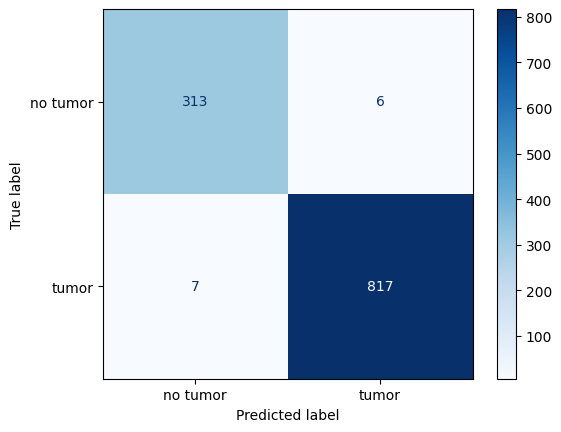

In [41]:
# Predictions on val_ds
y_true_presence = []
y_pred_presence = []

for x_batch, y_batch in val_ds:
    preds = model.predict(x_batch)
    y_true_presence.extend(y_batch["tumor_presence"].numpy().astype(int).flatten())
    y_pred_presence.extend((preds['tumor_presence'] > 0.5).astype(int).flatten())

cm = confusion_matrix(y_true_presence, y_pred_presence)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["no tumor", "tumor"])
disp.plot(cmap='Blues')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

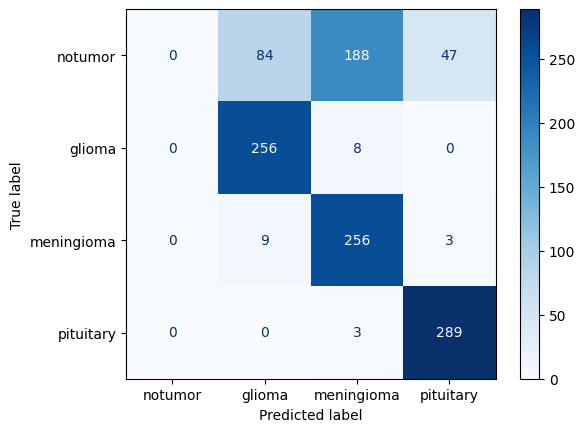

In [42]:
# Predictions on val_ds
y_true_type = []
y_pred_type = []

for x_batch, y_batch in val_ds:
    preds = model.predict(x_batch)
    y_true_type.extend(y_batch['tumor_type'].numpy())
    y_pred_type.extend(preds['tumor_type'].argmax(axis=-1))

cm = confusion_matrix(y_true_type, y_pred_type)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES)
disp.plot(cmap='Blues')

### Grad-CAM

In [43]:
model = get_model_built(
    IMG_SIZE,
    ARTEFACTS_DIR,
    FREEZE_BACKBONE=False
)

model.load_weights(
    BEST_HEAD_DIR + "/brain_tumor_heads.weights.h5"
)

print("✅ Model reconstructed + weights loaded")

✅ RadImageNet DenseNet121 loaded successfully
✅ Model reconstructed + weights loaded


In [44]:
val_ds = load_tfrecord_dataset(
    VAL_DIR,
    shuffle=False,
    batch_size=BATCH_SIZE,
    repeat=False
).prefetch(tf.data.AUTOTUNE)

In [45]:
idx = 1121
test_img = get_image_by_index(val_ds, idx)
print(test_img.shape)

NameError: name 'get_image_by_index' is not defined

In [ ]:
get_grad_cam_overlay_img(model, test_img, head_name='tumor_presence', grad_cam_function=compute_gradcam)

In [ ]:
get_grad_cam_overlay_img(model, test_img, head_name='tumor_type', grad_cam_function=compute_gradcam)

## Confidence intervals

In [46]:
model = get_model_built(
    IMG_SIZE,
    ARTEFACTS_DIR,
    FREEZE_BACKBONE=False
)

model.load_weights(
    BEST_HEAD_DIR + "/brain_tumor_heads.weights.h5"
)

print("✅ Model reconstructed + weights loaded")

✅ RadImageNet DenseNet121 loaded successfully
✅ Model reconstructed + weights loaded


In [47]:
def wilson_ci(successes, n, confidence=0.95):
    if n == 0:
        return (np.nan, np.nan)

    z = norm.ppf(1 - (1 - confidence) / 2)
    p = successes / n
    
    denominator = 1 + z**2 / n
    center = (p + z**2 / (2*n)) / denominator
    margin = (
        z * np.sqrt((p*(1-p) + z**2/(4*n)) / n)
    ) / denominator
    
    return center - margin, center + margin


In [58]:
def bootstrap_ci(y_true, y_pred, metric_fn, 
                 n_boot=1000, confidence=0.95, random_state=42):
    
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    
    rng = np.random.RandomState(random_state)
    scores = []
    n = len(y_true)
    
    for _ in range(n_boot):
        indices = rng.choice(n, n, replace=True)
        score = metric_fn(
            y_true[indices],
            y_pred[indices]
        )
        scores.append(score)
    
    lower = np.percentile(scores, (1 - confidence) / 2 * 100)
    upper = np.percentile(scores, (1 + confidence) / 2 * 100)
    
    return lower, upper

In [49]:
def evaluate_with_ci(y_true, y_pred,
    average="macro",   # "binary", "macro", "weighted"
    confidence=0.95):
    
    results = {}
    
    # Accuracy
    acc = accuracy_score(y_true, y_pred)
    n = len(y_true)
    acc_ci = wilson_ci(int(acc*n), n, confidence)
    
    results["accuracy"] = {
        "value": acc,
        "ci": acc_ci
    }
    
    # Precision
    prec = precision_score(y_true, y_pred, average=average)
    prec_ci = bootstrap_ci(
        y_true, y_pred,
        lambda yt, yp: precision_score(yt, yp, average=average),
        confidence=confidence
    )
    
    results["precision"] = {
        "value": prec,
        "ci": prec_ci
    }
    
    # Recall
    rec = recall_score(y_true, y_pred, average=average)
    rec_ci = bootstrap_ci(
        y_true, y_pred,
        lambda yt, yp: recall_score(yt, yp, average=average),
        confidence=confidence
    )
    
    results["recall"] = {
        "value": rec,
        "ci": rec_ci
    }
    
    # F1
    f1 = f1_score(y_true, y_pred, average=average)
    f1_ci = bootstrap_ci(
        y_true, y_pred,
        lambda yt, yp: f1_score(yt, yp, average=average),
        confidence=confidence
    )
    
    results["f1"] = {
        "value": f1,
        "ci": f1_ci
    }
    
    return results


In [72]:
presence_results = evaluate_with_ci(
    y_true_presence,
    y_pred_presence,
    average="binary"
)

for stat_name, stats in presence_results.items():
    print(f"\nStat: {stat_name}")
    print(f"Recall: {stats['value']:.4f}")
    print(f"95% CI: [{stats['ci'][0]:.4f}, {stats['ci'][1]:.4f}]")


Stat: accuracy
Recall: 0.9886
95% CI: [0.9806, 0.9933]

Stat: precision
Recall: 0.9927
95% CI: [0.9867, 0.9976]

Stat: recall
Recall: 0.9915
95% CI: [0.9849, 0.9965]

Stat: f1
Recall: 0.9921
95% CI: [0.9876, 0.9958]


In [63]:
def mask_no_tumor(y_true, y_pred, no_tumor_label=0):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    mask = y_true != no_tumor_label

    return y_true[mask], y_pred[mask]

In [71]:
y_true_type_masked, y_pred_type_masked = mask_no_tumor(
    y_true_type,
    y_pred_type
)

type_results = evaluate_with_ci(
    y_true_type_masked,
    y_pred_type_masked,
    average="macro"
)

for stat_name, stats in type_results.items():
    print(f"\nStat: {stat_name}")
    print(f"Recall: {stats['value']:.4f}")
    print(f"95% CI: [{stats['ci'][0]:.4f}, {stats['ci'][1]:.4f}]")


Stat: accuracy
Recall: 0.9721
95% CI: [0.9585, 0.9813]

Stat: precision
Recall: 0.9715
95% CI: [0.9601, 0.9831]

Stat: recall
Recall: 0.9715
95% CI: [0.9600, 0.9832]

Stat: f1
Recall: 0.9715
95% CI: [0.9601, 0.9830]


In [53]:
def per_class_recall_ci(y_true, y_pred, confidence=0.95):
    
    cm = confusion_matrix(y_true, y_pred)
    recalls = {}
    
    for i in range(len(cm)):
        tp = cm[i, i]
        fn = cm[i, :].sum() - tp
        n = tp + fn
        
        recalls[i] = {
            "value": tp / n,
            "ci": wilson_ci(tp, n, confidence)
        }
    
    return recalls

In [68]:
recall_stats = per_class_recall_ci(
    y_true_type_masked,
    y_pred_type_masked,
    confidence=0.95
)

for class_idx, stats in recall_stats.items():
    print(f"\nClass: {CLASSES[class_idx+1]}")
    print(f"Recall: {stats['value']:.4f}")
    print(f"95% CI: [{stats['ci'][0]:.4f}, {stats['ci'][1]:.4f}]")



Class: glioma
Recall: 0.9697
95% CI: [0.9414, 0.9846]

Class: meningioma
Recall: 0.9552
95% CI: [0.9234, 0.9742]

Class: pituitary
Recall: 0.9897
95% CI: [0.9702, 0.9965]


## Medical Pipeline

In [55]:
model = get_model_built(
    IMG_SIZE,
    ARTEFACTS_DIR,
    FREEZE_BACKBONE=False
)

model.load_weights(
    BEST_HEAD_DIR + "/brain_tumor_heads.weights.h5"
)

print("✅ Model reconstructed + weights loaded")

✅ RadImageNet DenseNet121 loaded successfully
✅ Model reconstructed + weights loaded
